<a href="https://colab.research.google.com/github/M-AyyanAsif/NETSOL_TASKS/blob/main/svm_student_v3_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 SVM Student Lab — Updated to Match the Lecture 17 Slides
### Build your intuition — step by step, starting with the salary data you already know

---

### 📌 What You Will Practise

| Concept | What it means in plain English | Slide |
|---|---|---|
| **Hyperplane & score** | The dividing line, written as `score = weight × column + … + constant` | Hyperplane, The Rule |
| **Margin** | The width of the empty street between the two groups | Anatomy of an SVM |
| **Support vectors** | The few dots touching the street edge — they alone decide where the street goes | Support Vectors |
| **Hard vs soft margin, C** | "No mistakes allowed" vs "a few mistakes are fine" — C is the strictness dial | Hard Margin, Soft Margin |
| **Kernels** | Linear, polynomial, radial (RBF): how the boundary is allowed to bend | Three Kernels |
| **gamma** | How far each dot's influence reaches in the RBF kernel | The RBF Dial Called Gamma |

### 🌍 Datasets We Use
| Dataset | What it is | Problem |
|---|---|---|
| **Salary data** | The same 20 people from the lecture (experience, education, age, certifications, salary) | Is this person a **High earner** (salary ≥ $55k)? |
| **Breast Cancer** | 569 patients, 30 medical measurements | Is the tumour malignant or benign? |
| **Iris Flowers** *(bonus)* | 150 flowers, 4 measurements | Which of 3 species is this flower? |

### 🗺️ The Plan
| Part | Tasks | Focus |
|---|---|---|
| **Part 1 — Salary data** | Tasks 1–5 | The same ideas as the slides, on 20 people you can check by hand |
| **Part 2 — Breast Cancer** | Tasks 6–8 (+ Task 9 bonus) | Do the same ideas hold on real medical data? |
| **Part 3 — Iris** | Task 10 (bonus) | Compare kernels on a 3-class problem |

**Core work = Tasks 1–8.** The two ⭐ bonus tasks are for fast finishers.

### 📋 How to work through this
- Read each **Background** section carefully — the concept is explained there
- Then do the numbered steps in the code cell
- **💬 Think About It** boxes have questions — write your answers in your notes or a markdown cell
- Hidden solutions are available if you are stuck — but try first!

---

In [1]:
# ╔═══════════════════════════════════════╗
# ║  RUN THIS CELL FIRST — every time!   ║
# ╚═══════════════════════════════════════╝
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import svm, datasets
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# ── The salary table from the lecture (20 people) ───────────────────────────
salary_columns = ['experience', 'education', 'age', 'certifications', 'salary']
salary_rows = [      # experience, education, age, certifications, salary ($k)
    (1,16,23,0,35), (2,16,24,1,40), (3,18,26,1,47), (4,16,27,2,51),
    (5,18,29,2,58), (6,18,31,3,62), (7,20,33,3,70), (8,20,35,4,75),   # rows 1-8: the original regression table
    (1,18,24,1,42), (2,20,26,2,52), (3,16,25,0,41), (4,20,28,3,60),
    (5,16,30,1,53), (6,16,32,1,56), (7,18,31,2,66), (8,16,36,2,64),
    (9,20,34,4,82), (10,18,38,3,80), (2,16,22,0,36), (9,16,40,1,68),  # rows 9-20: added for classification
]
HI, LO = '#2E8B57', '#B23A48'      # green square = High earner, red circle = Not high

# ── Real datasets ───────────────────────────────────────────────────────────
cancer = datasets.load_breast_cancer()
iris   = datasets.load_iris()

print('✅ Ready to go!')
print(f'  Salary table  : {len(salary_rows)} people, columns = {salary_columns}')
print(f'  Breast Cancer : {cancer.data.shape}')
print(f'  Iris          : {iris.data.shape}')

✅ Ready to go!
  Salary table  : 20 people, columns = ['experience', 'education', 'age', 'certifications', 'salary']
  Breast Cancer : (569, 30)
  Iris          : (150, 4)


---
---
# 💼 PART 1 — The Salary Data
## "Is this person a High earner?"

You already know these 20 people from the regression lectures. Now the question changes from *"how much?"* to *"which group?"*.  
Because there are only 20 dots and 2 columns, you can **check every number by hand** — perfect for understanding what SVM really does.

---

---
## ✏️ Task 1 — Look Before You Train: The Salary Data

### Background
Every classification problem starts with a **label** — the "right answer" the computer learns from.  
Here the label is: **High earner = salary of $55k or more**.

To draw the data on paper we use just **two columns**: `experience` (x-axis) and `certifications` (y-axis).  
Each dot is one person. We use the same colours as the slides: **green square** = High earner, **red circle** = Not high.

### Steps
1. Build a DataFrame `df` from `salary_rows` with the column names in `salary_columns`
2. Add a column `high_earner` that is `1` when salary ≥ 55 and `0` otherwise
3. Print how many High earners and how many Not high there are
4. Create `X` (the two columns `experience` and `certifications`, as a NumPy array) and `y` (the `high_earner` column)
5. Make a scatter plot of the 20 people with the slide colours and a legend
6. Look at your plot: where would you draw a straight line to separate the two groups?

> 💡 `df["salary"] >= 55` gives True/False; `.astype(int)` turns it into 1/0  
> 💡 `ax.scatter(x, y, marker="s")` draws squares, `marker="o"` draws circles

High Earner Counts:
high_earner
High Earner (≥55k)    11
Not High (<55k)        9
Name: count, dtype: int64


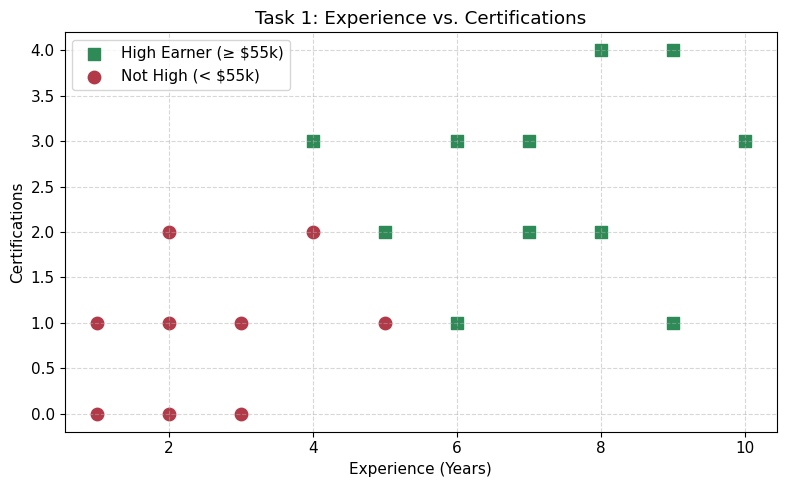

In [2]:
# ── Step 1: Create DataFrame ────────────────────────────────────────────────
df = pd.DataFrame(salary_rows, columns=salary_columns)

# ── Step 2: Add binary target column (1 for ≥ $55k, 0 otherwise) ─────────────
df['high_earner'] = (df['salary'] >= 55).astype(int)

# ── Step 3: Print class distribution ────────────────────────────────────────
print("High Earner Counts:")
print(df['high_earner'].value_counts().rename({1: 'High Earner (≥55k)', 0: 'Not High (<55k)'}))

# ── Step 4: Extract features (X) and label (y) ──────────────────────────────
X = df[['experience', 'certifications']].values
y = df['high_earner'].values

# ── Step 5: Plot the data ───────────────────────────────────────────────────
plt.figure(figsize=(8, 5))

# Plot High Earners (y = 1) as green squares
plt.scatter(
    X[y == 1, 0], X[y == 1, 1],
    c=HI, marker='s', s=80, label='High Earner (≥ $55k)'
)

# Plot Not High Earners (y = 0) as red circles
plt.scatter(
    X[y == 0, 0], X[y == 0, 1],
    c=LO, marker='o', s=80, label='Not High (< $55k)'
)

plt.title("Task 1: Experience vs. Certifications")
plt.xlabel("Experience (Years)")
plt.ylabel("Certifications")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**💬 Think About It:**

*Are the two groups roughly balanced?*  
*Where do the green squares sit compared with the red circles?*  
*Could one straight line separate them perfectly? Roughly where would it go?*

<details><summary>💡 Reveal Solution</summary>

```python
df = pd.DataFrame(salary_rows, columns=salary_columns)
df.index = df.index + 1                      # person numbers 1..20
df.index.name = 'person'
df['high_earner'] = (df['salary'] >= 55).astype(int)
display(df)
print('High earners:', df['high_earner'].sum(), '| Not high:', (df['high_earner'] == 0).sum())

X = df[['experience', 'certifications']].values     # the two columns we draw
y = df['high_earner'].values                         # 1 = High earner, 0 = Not high

fig, ax = plt.subplots(figsize=(8, 5))
hi = (y == 1)
ax.scatter(X[hi, 0],  X[hi, 1],  marker='s', s=120, c=HI, edgecolors='white', label='High earner (≥ $55k)')
ax.scatter(X[~hi, 0], X[~hi, 1], marker='o', s=120, c=LO, edgecolors='white', label='Not high')
for person, (a, b) in zip(df.index, X):
    ax.text(a + 0.12, b + 0.12, str(person), fontsize=8, color='#555')
ax.set_xlabel('Experience (years)'); ax.set_ylabel('Certifications')
ax.set_title('The salary data with a Yes/No label', fontweight='bold')
ax.grid(alpha=0.3); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 2 — Find the Hyperplane, the Margin and the Support Vectors

### Background
On the slides, SVM found this rule for our data:

```
score = 2 × experience + 2 × certifications − 13
```

- **Hyperplane** = where the score is exactly **0** (for 2 columns this is a line)
- **Margin edges** = where the score is **+1** and **−1**; the **margin** is the width of the street between them: `2 ÷ √(w₁² + w₂²)`
- **Support vectors** = the dots that sit on a margin edge (score = ±1)
- **Hard margin** = no mistakes allowed. In scikit-learn we get it by using a *very large* C, such as `1_000_000`

Now you will make the computer find these numbers itself and check them against the slides.

> ⚠️ In this task we do **not** scale the data, so the weights stay readable (the slides did the same).

### Steps
1. Using `X` and `y` from Task 1, train `SVC(kernel="linear", C=1_000_000)`
2. Print the **weights** (`clf.coef_`) and the **constant** (`clf.intercept_`). Do they match 2, 2 and −13?
3. Compute the **margin width** = `2 / np.linalg.norm(clf.coef_[0])`
4. Use `clf.decision_function(X)` to get every person's score. Print the persons whose score is exactly +1 or −1 (use `np.abs(np.abs(scores) - 1) < 1e-3`)
5. Print `clf.support_` (the support vectors scikit-learn reports). Compare with your list from step 4
6. Classify the **tricky person** (3 years of experience, 4 certifications): print their score and the predicted group
7. Plot the data, the hyperplane (solid line), the two margin edges (dashed) and circle the dots on the edges

> 💡 `clf.coef_[0]` → the two weights  |  `clf.intercept_[0]` → the constant  
> 💡 To draw the line for score = `off`: `y = (-(w[0]*x + b) + off) / w[1]`

Weights (w1, w2): [2.00, 2.00]
Constant (b): -13.00
Margin width: 0.7071

Manual Support Vector Indices (Score = ±1): [ 3  4 11 12 13]
Sklearn Support Vector Indices: [ 3 12  4]

Tricky Person (Exp=3, Certs=4):
 - Score: 1.00
 - Predicted Group: High Earner (1)


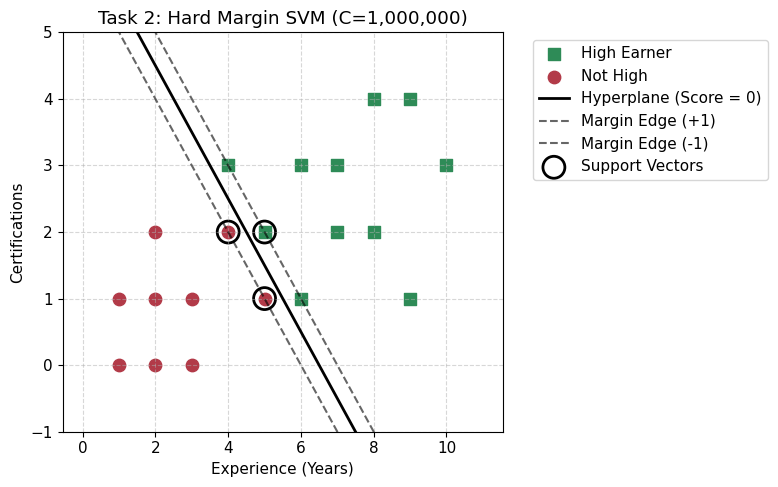

In [3]:
# ── Step 1: Train the SVM with a Hard Margin ────────────────────────────────
# C=1_000_000 enforces a "strict" hard margin (no mistakes allowed)
clf = SVC(kernel="linear", C=1_000_000)
clf.fit(X, y)

# ── Step 2: Extract Weights and Constant ────────────────────────────────────
w = clf.coef_[0]        # w[0] is experience weight, w[1] is certifications weight
b = clf.intercept_[0]   # b is the constant/intercept

print(f"Weights (w1, w2): [{w[0]:.2f}, {w[1]:.2f}]")
print(f"Constant (b): {b:.2f}")
# Expected: Weights close to [2.00, 2.00], Constant close to -13.00

# ── Step 3: Compute the Margin Width ────────────────────────────────────────
# Margin width formula: 2 / ||w||
margin_width = 2 / np.linalg.norm(w)
print(f"Margin width: {margin_width:.4f}")

# ── Step 4: Find Support Vectors Manually (Score = ±1) ──────────────────────
scores = clf.decision_function(X)
# Find where the absolute score is exactly 1 (accounting for tiny math errors with 1e-3)
is_on_margin = np.abs(np.abs(scores) - 1) < 1e-3
manual_sv_indices = np.where(is_on_margin)[0]
print(f"\nManual Support Vector Indices (Score = ±1): {manual_sv_indices}")

# ── Step 5: Check Scikit-Learn's Support Vectors ────────────────────────────
print(f"Sklearn Support Vector Indices: {clf.support_}")

# ── Step 6: Classify the Tricky Person ──────────────────────────────────────
tricky_person = np.array([[3, 4]])  # 3 years experience, 4 certifications
tricky_score = clf.decision_function(tricky_person)[0]
tricky_pred = clf.predict(tricky_person)[0]
print(f"\nTricky Person (Exp=3, Certs=4):")
print(f" - Score: {tricky_score:.2f}")
print(f" - Predicted Group: {'High Earner (1)' if tricky_pred == 1 else 'Not High (0)'}")

# ── Step 7: Plot Data, Hyperplane, and Margins ──────────────────────────────
plt.figure(figsize=(8, 5))

# Scatter plot of the data
plt.scatter(X[y == 1, 0], X[y == 1, 1], c=HI, marker='s', s=80, label='High Earner')
plt.scatter(X[y == 0, 0], X[y == 0, 1], c=LO, marker='o', s=80, label='Not High')

# Create x-values to draw the lines across the graph
x_vals = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])

# Calculate y-values for Hyperplane and Margins using the formula provided
# y = (-(w[0]*x + b) + offset) / w[1]
y_hyperplane = (-(w[0] * x_vals + b) + 0) / w[1]
y_margin_pos = (-(w[0] * x_vals + b) + 1) / w[1]
y_margin_neg = (-(w[0] * x_vals + b) - 1) / w[1]

# Plot the lines
plt.plot(x_vals, y_hyperplane, 'k-', linewidth=2, label='Hyperplane (Score = 0)')
plt.plot(x_vals, y_margin_pos, 'k--', alpha=0.6, label='Margin Edge (+1)')
plt.plot(x_vals, y_margin_neg, 'k--', alpha=0.6, label='Margin Edge (-1)')

# Circle the support vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=250, facecolors='none', edgecolors='k', linewidths=2,
            label='Support Vectors')

plt.title("Task 2: Hard Margin SVM (C=1,000,000)")
plt.xlabel("Experience (Years)")
plt.ylabel("Certifications")
plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)  # Keep view focused
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**💬 Think About It:**

*Do the weights and constant match the slide rule?*  
*How wide is the street?*  
*How many dots sit exactly on a street edge? Does scikit-learn list all of them as support vectors? (Look carefully at the two lists.)*  
*What does a score of +1 for the tricky person tell you about where they stand?*

<details><summary>💡 Reveal Solution</summary>

```python
clf = SVC(kernel='linear', C=1_000_000).fit(X, y)       # very large C = hard margin
w = clf.coef_[0]; b = clf.intercept_[0]
print(f'score = {w[0]:.2f} × experience + {w[1]:.2f} × certifications {b:+.2f}')

width = 2 / np.linalg.norm(w)
print(f'Margin width = 2 / ‖w‖ = {width:.2f}')

scores = clf.decision_function(X)
edge = np.where(np.abs(np.abs(scores) - 1) < 1e-3)[0]
print('Persons exactly on a street edge (|score| = 1):', [int(i) + 1 for i in edge])
print('Persons listed by scikit-learn as support vectors :', sorted(int(i) + 1 for i in clf.support_))
print('(Two edge dots tie exactly with the others, so scikit-learn does not need them to define the street.)')

tricky = [[3, 4]]
print(f'\nTricky person: score = {clf.decision_function(tricky)[0]:+.2f}  ->',
      'High earner' if clf.predict(tricky)[0] == 1 else 'Not high')

xs = np.linspace(0, 11, 100)
line = lambda off: (-(w[0] * xs + b) + off) / w[1]
fig, ax = plt.subplots(figsize=(9, 5.5))
hi = (y == 1)
ax.fill_between(xs, line(-1), line(1), color='#C98A2C', alpha=0.15)
ax.plot(xs, line(0), 'k-', lw=2.5, label='Hyperplane (score = 0)')
ax.plot(xs, line(1), '--', color='#C98A2C', lw=1.6, label='Margin edges (score = ±1)')
ax.plot(xs, line(-1), '--', color='#C98A2C', lw=1.6)
ax.scatter(X[hi, 0],  X[hi, 1],  marker='s', s=110, c=HI, edgecolors='white', zorder=3)
ax.scatter(X[~hi, 0], X[~hi, 1], marker='o', s=110, c=LO, edgecolors='white', zorder=3)
ax.scatter(X[edge, 0], X[edge, 1], s=380, facecolors='none', edgecolors='navy', lw=2.2, zorder=4, label='Dots on the edge')
ax.scatter(*tricky[0], marker='*', s=350, c='gold', edgecolors='navy', zorder=5, label='Tricky person')
ax.set_xlim(0, 11); ax.set_ylim(-0.7, 5)
ax.set_xlabel('Experience (years)'); ax.set_ylabel('Certifications')
ax.set_title('Hyperplane, margin and support vectors on the salary data', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 3 — Hard Margin Breaks, Soft Margin Saves the Day (the C Dial)

### Background
A **hard margin** works only if one straight line can separate the groups *perfectly*. Our 20 people can be separated — but real data has odd people.

Meet the **odd person**: **8 years of experience, 0 certifications, Not high** (invented for teaching; not in the table).  
Add them and **no straight line gets everyone right**. A hard margin has no answer.

The fix is the **soft margin**, controlled by the dial **C**:

| | Small C | Large C |
|---|---|---|
| Attitude | "A few mistakes are fine" | "Never tolerate a mistake" |
| Street | **Wide** | **Thin** |
| Risk | Too simple (underfitting) | Tilts to please one odd dot (overfitting) |

### Steps
1. Make `X_odd` and `y_odd`: add the odd person (8, 0) with label `0` to `X` and `y` (21 people)
2. For each `C` in `[0.01, 0.1, 1, 10, 1000, 1_000_000]` train a **linear** SVC on the 21 people and record: training accuracy, number of support vectors, margin width
3. Print a neat table of the results
4. Do the **same table for the original 20 people** (no odd person) and compare the two tables
5. As C grows, what happens to the margin width and to the number of support vectors?
6. With the odd person, can the training accuracy ever reach 100%, even at `C = 1_000_000`?

> 💡 `np.vstack([X, [8, 0]])` adds a row; `np.append(y, 0)` adds a label  
> 💡 `clf.score(X, y)` → training accuracy  |  `len(clf.support_)` → number of support vectors

In [4]:
# ── Step 1: Create the 21-person dataset with the "odd person" ─────────────
# Add person with 8 years experience, 0 certifications, who is NOT a high earner (y=0)
X_odd = np.vstack([X, [8, 0]])
y_odd = np.append(y, 0)

# ── Helper function to evaluate SVM across different C values ───────────────
def evaluate_c_values(X_data, y_data):
    c_values = [0.01, 0.1, 1, 10, 1000, 1_000_000]
    results = []

    for C in c_values:
        clf = SVC(kernel="linear", C=C)
        clf.fit(X_data, y_data)

        acc = clf.score(X_data, y_data)
        n_sv = len(clf.support_)
        margin = 2 / np.linalg.norm(clf.coef_[0])

        results.append({
            "C Value": C,
            "Accuracy": f"{acc * 100:.1f}%",
            "Support Vectors": n_sv,
            "Margin Width": f"{margin:.4f}"
        })

    return pd.DataFrame(results)

# ── Step 2 & 3: Run evaluation and display comparison tables ────────────────
print("=== Table 1: Original 20 People (Linearly Separable) ===")
df_orig = evaluate_c_values(X, y)
print(df_orig.to_string(index=False))

print("\n=== Table 2: 21 People (With Odd Person [8, 0]) ===")
df_odd = evaluate_c_values(X_odd, y_odd)
print(df_odd.to_string(index=False))

=== Table 1: Original 20 People (Linearly Separable) ===
   C Value Accuracy  Support Vectors Margin Width
      0.01    95.0%               16       7.5271
      0.10    95.0%                8       4.0000
      1.00    90.0%                5       1.4142
     10.00   100.0%                3       0.7071
   1000.00   100.0%                3       0.7071
1000000.00   100.0%                3       0.7071

=== Table 2: 21 People (With Odd Person [8, 0]) ===
   C Value Accuracy  Support Vectors Margin Width
      0.01    90.5%               18       7.6157
      0.10    95.2%               10       3.5368
      1.00    95.2%                7       1.4857
     10.00    95.2%                4       0.7071
   1000.00    95.2%                4       0.4474
1000000.00    95.2%                4       0.4474


**💬 Think About It:**

*Why can the 21-person data never reach 100% training accuracy, even with the largest C?*  
*What happens to the street width as C gets larger? To the number of support vectors?*  
*On the original 20 people, `C = 1` does not reach 100% but `C = 10` does. Why would a soft margin choose a wider street over a perfect score?*  
*Which C would you pick for new, unseen people, and why?*

<details><summary>💡 Reveal Solution</summary>

```python
X_odd = np.vstack([X, [8, 0]])
y_odd = np.append(y, 0)
print('21 people = original 20 + odd person (8 yrs, 0 certs, Not high)\n')

def c_table(Xd, yd, title):
    print(title)
    print(f'{"C":>10}  {"Train acc":>9}  {"#SVs":>5}  {"Street width":>12}')
    print('-' * 44)
    widths = []
    for C in [0.01, 0.1, 1, 10, 1000, 1_000_000]:
        m = SVC(kernel='linear', C=C).fit(Xd, yd)
        wd = 2 / np.linalg.norm(m.coef_[0])
        widths.append(wd)
        print(f'{C:>10g}  {m.score(Xd, yd):>9.3f}  {len(m.support_):>5}  {wd:>12.2f}')
    print()
    return widths

w_odd   = c_table(X_odd, y_odd, 'WITH the odd person (21 people):')
w_clean = c_table(X, y,         'ORIGINAL 20 people:')

Cs = [0.01, 0.1, 1, 10, 1000, 1_000_000]
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(Cs, w_clean, 'o-', color=HI, label='20 people')
ax.semilogx(Cs, w_odd, 's-', color=LO, label='21 people (with odd person)')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('Street width')
ax.set_title('Larger C  →  thinner street', fontweight='bold')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
```
</details>

---
## ✏️ Task 4 — Three Kernels on the Salary Data

### Background
A **kernel** decides how the boundary is allowed to bend:

| Kernel | Plain-words idea | Boundary |
|---|---|---|
| **Linear** | A straight cut. No extra columns | Straight line |
| **Polynomial** | Adds columns made by multiplying columns together | Smooth curves |
| **Radial (RBF)** | Every dot spreads a bubble of influence that fades with distance | Almost any shape |

How do we compare models fairly? A model that memorises the training data scores 100% *on that data* — which proves nothing.  
So we use a **left-out score**: remove one person, train on the other 19, test on the removed person, repeat for all 20, and average.  
In scikit-learn this is `cross_val_score(pipe, X, y, cv=LeaveOneOut())`.

⚠️ Kernels use distances, so **scale first**. `make_pipeline(StandardScaler(), SVC(...))` does that every time.

### Steps
1. Build three SVC settings: `kernel="linear"`, `kernel="poly", degree=3, coef0=1`, `kernel="rbf", gamma="scale"`
2. For `C = 1` **and** `C = 10`, for each kernel: build `make_pipeline(StandardScaler(), SVC(...))`
3. Record the **training score** (fit on all 20, score on all 20) and the **left-out score** (`LeaveOneOut`)
4. Also print what each model says about the **tricky person** (3 years, 4 certifications)
5. Print a table: kernel × C → training score, left-out score, tricky person
6. Which kernel wins at `C = 1`? Which wins at `C = 10`?

> 💡 `cross_val_score(pipe, X, y, cv=LeaveOneOut()).mean()` → the left-out score  
> 💡 `pipe.predict([[3, 4]])` → answer for one new person (1 = High earner)

In [5]:
# ── Define kernel configurations ─────────────────────────────────────────────
kernels_config = [
    ("Linear", {"kernel": "linear"}),
    ("Polynomial (d=3)", {"kernel": "poly", "degree": 3, "coef0": 1}),
    ("RBF", {"kernel": "rbf", "gamma": "scale"}),
]

c_values = [1, 10]
tricky_person = np.array([[3, 4]])  # 3 years experience, 4 certifications
results = []

# ── Evaluate each combination ───────────────────────────────────────────────
for C in c_values:
    for kernel_name, params in kernels_config:
        # Scale data and fit SVC in a single pipeline
        pipe = make_pipeline(StandardScaler(), SVC(C=C, **params))

        # 1. Training score on all 20 samples
        pipe.fit(X, y)
        train_acc = pipe.score(X, y)

        # 2. Leave-One-Out (LOO) cross-validation score
        loo_acc = cross_val_score(pipe, X, y, cv=LeaveOneOut()).mean()

        # 3. Classify the tricky person
        tricky_pred = pipe.predict(tricky_person)[0]
        tricky_label = "High Earner (1)" if tricky_pred == 1 else "Not High (0)"

        results.append(
            {
                "Kernel": kernel_name,
                "C": C,
                "Train Score": f"{train_acc * 100:.1f}%",
                "LOO Score": f"{loo_acc * 100:.1f}%",
                "Tricky Person (3, 4)": tricky_label,
            }
        )

# ── Display the comparison table ────────────────────────────────────────────
df_task4 = pd.DataFrame(results)
print(df_task4.to_string(index=False))

          Kernel  C Train Score LOO Score Tricky Person (3, 4)
          Linear  1       95.0%     85.0%      High Earner (1)
Polynomial (d=3)  1       90.0%     85.0%      High Earner (1)
             RBF  1      100.0%     85.0%      High Earner (1)
          Linear 10      100.0%    100.0%      High Earner (1)
Polynomial (d=3) 10      100.0%     95.0%      High Earner (1)
             RBF 10      100.0%     80.0%      High Earner (1)


**💬 Think About It:**

*At C = 1, do the kernels differ in left-out score? At C = 10?*  
*RBF reaches 100% training score. Does that make it the best model? What does the left-out score say?*  
*Our data can already be cut by a straight line. Why might the simplest kernel win?*  
*With only 20 people, how many percentage points is one person worth?*

<details><summary>💡 Reveal Solution</summary>

```python
kernels = {
    'linear':          dict(kernel='linear'),
    'poly (degree 3)': dict(kernel='poly', degree=3, coef0=1),
    'rbf':             dict(kernel='rbf', gamma='scale'),
}
print(f'{"Kernel":<16}{"C":>4}  {"Training":>9}  {"Left-out":>9}  Tricky person')
print('-' * 56)
for C in (1, 10):
    for name, kw in kernels.items():
        pipe = make_pipeline(StandardScaler(), SVC(C=C, **kw))
        left_out = cross_val_score(pipe, X, y, cv=LeaveOneOut()).mean()
        pipe.fit(X, y)
        train = pipe.score(X, y)
        tricky_ans = 'High' if pipe.predict([[3, 4]])[0] == 1 else 'Not high'
        print(f'{name:<16}{C:>4}  {train:>9.2f}  {left_out:>9.2f}  {tricky_ans}')
    print()
print('One person = 5 points with only 20 people, so treat small gaps with care.')
```
</details>

---
## ✏️ Task 5 — The RBF Dial Called Gamma

### Background
**gamma** controls how far each dot's influence reaches in the RBF kernel:

```
SMALL gamma                         LARGE gamma
Huge bubbles                        Tiny bubbles
Smooth, too-simple boundary         An island around nearly every dot
UNDERFITTING                        OVERFITTING (memorising)
```

This is the same danger you met with **K = 1 in KNN**: a model that copies every dot exactly looks perfect on old data and fails on new data.

### Steps
1. For `gamma` in `[0.01, 0.1, 1, 10, 50]`, build `make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=gamma))`
2. Record the **training score** and the **left-out score** (`LeaveOneOut`) for each gamma
3. Print a table and make a line plot: training score (red) and left-out score (blue) against gamma on a log x-axis
4. Which gamma memorises the 20 people? Which gamma gives the best left-out score?
5. What does the tricky person get at each gamma?

> 💡 `np.argmax(list)` gives the position of the largest value  
> 💡 `ax.semilogx(x, y)` draws a line with a log-scale x-axis

=== Task 5: The RBF Dial Called Gamma ===
 Gamma Train Score LOO Score Tricky Person (3, 4)
  0.01       80.0%     55.0%      High Earner (1)
  0.10       95.0%     95.0%      High Earner (1)
  1.00      100.0%     80.0%      High Earner (1)
 10.00      100.0%     65.0%      High Earner (1)
 50.00      100.0%     55.0%      High Earner (1)


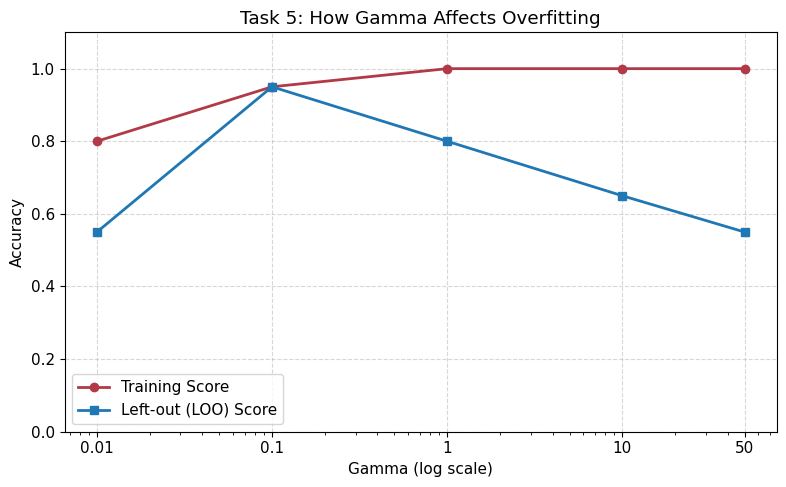

In [6]:
# ── Setup parameters ────────────────────────────────────────────────────────
gamma_values = [0.01, 0.1, 1, 10, 50]
tricky_person = np.array([[3, 4]])  # 3 years experience, 4 certifications

results = []
train_scores = []
loo_scores = []

# ── Evaluate each Gamma value ───────────────────────────────────────────────
for g in gamma_values:
    # Build pipeline: Scale data first, then apply RBF SVM
    pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=g))

    # 1. Training score
    pipe.fit(X, y)
    train_acc = pipe.score(X, y)
    train_scores.append(train_acc)

    # 2. Leave-One-Out (LOO) score
    loo_acc = cross_val_score(pipe, X, y, cv=LeaveOneOut()).mean()
    loo_scores.append(loo_acc)

    # 3. Classify tricky person
    tricky_pred = pipe.predict(tricky_person)[0]
    tricky_label = "High Earner (1)" if tricky_pred == 1 else "Not High (0)"

    # Store data for the table
    results.append({
        "Gamma": g,
        "Train Score": f"{train_acc * 100:.1f}%",
        "LOO Score": f"{loo_acc * 100:.1f}%",
        "Tricky Person (3, 4)": tricky_label
    })

# ── Display the Table ───────────────────────────────────────────────────────
df_gamma = pd.DataFrame(results)
print("=== Task 5: The RBF Dial Called Gamma ===")
print(df_gamma.to_string(index=False))

# ── Plot the Results (Log Scale X-Axis) ─────────────────────────────────────
plt.figure(figsize=(8, 5))

# Plot Training (red) and Left-out (blue) scores
plt.semilogx(gamma_values, train_scores, color=LO, marker='o', label='Training Score', linewidth=2)
plt.semilogx(gamma_values, loo_scores, color='#1f77b4', marker='s', label='Left-out (LOO) Score', linewidth=2)

plt.title("Task 5: How Gamma Affects Overfitting")
plt.xlabel("Gamma (log scale)")
plt.ylabel("Accuracy")

# Explicitly set x-ticks to our gamma values so they are easy to read
plt.xticks(gamma_values, labels=gamma_values)
plt.ylim(0, 1.1)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**💬 Think About It:**

*At which gamma is the training score perfect but the left-out score poor? What is this called?*  
*What is wrong with the smallest gamma?*  
*How is a huge gamma similar to K = 1 in KNN?*  
*Which two dials would you tune together for an RBF model?*

<details><summary>💡 Reveal Solution</summary>

```python
gammas = [0.01, 0.1, 1, 10, 50]
tr_list, lo_list = [], []
print(f'{"gamma":>7}  {"Training":>9}  {"Left-out":>9}  Tricky person')
print('-' * 46)
for g in gammas:
    pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma=g))
    lo = cross_val_score(pipe, X, y, cv=LeaveOneOut()).mean()
    pipe.fit(X, y)
    tr = pipe.score(X, y)
    tr_list.append(tr); lo_list.append(lo)
    ans = 'High' if pipe.predict([[3, 4]])[0] == 1 else 'Not high'
    print(f'{g:>7g}  {tr:>9.2f}  {lo:>9.2f}  {ans}')

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.semilogx(gammas, tr_list, 'o-', color='#E63946', label='Training score')
ax.semilogx(gammas, lo_list, 's-', color='#457B9D', label='Left-out score')
best_g = gammas[int(np.argmax(lo_list))]
ax.axvline(best_g, color='green', ls='--', lw=2, label=f'Best gamma = {best_g}')
ax.set_xlabel('gamma (log scale)'); ax.set_ylabel('Score')
ax.set_title('RBF on the salary data: how gamma changes the score', fontweight='bold')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
print(f'\nBest gamma = {best_g}  |  gamma = 50 memorises the 20 people but does badly on a left-out person.')
```
</details>

---
---
# 🏥 PART 2 — Breast Cancer
## "Can measurements of a tumour cell tell us if it is dangerous?"

Doctors take 30 measurements from each tumour cell (size, texture, smoothness, etc.)  
Your job: train an SVM to classify each tumour as **Malignant** (dangerous) or **Benign** (safe).

The salary data had 20 people and 2 columns. This one has **569 patients and 30 columns** — do the same ideas still hold?

---

---
## ✏️ Task 6 — Look Before You Train, and Prove That Scaling Matters

### Background
Two things matter before training any model:

1. **Class balance.** If 95% of samples were benign, a model that always says "benign" would be 95% accurate and still miss every cancer.
2. **Feature ranges.** SVM kernels use **distances**. If one column ranges 0–0.1 and another 0–4000, the big one drowns out the small one. `StandardScaler` fixes this: mean 0, standard deviation 1.

⚠️ **The golden rule:** fit the scaler on the **training data only**, then apply it to the test data.

```
WRONG ❌:  scaler.fit(ALL data) → then split
RIGHT  ✅:  split first → scaler.fit(X_train) → scaler.transform(X_test)
```

### Steps
1. Print: number of samples, number of features, class names, and the number (and %) of samples in each class
2. Print the smallest and largest **range** (max − min) among the 30 features. Are they on similar scales?
3. Split 80% train / 20% test with `random_state=42`. Name them `X_tr, X_te, y_tr, y_te`
4. Scale: fit a `StandardScaler` on `X_tr` only. Create `X_tr_s` and `X_te_s`
5. Train **four** models with `C = 1`: linear on raw data, linear on scaled data, RBF on raw data, RBF on scaled data
6. Print the four test accuracies in a small table. For which kernel did scaling help?

> 💡 `cancer.data.max(axis=0) - cancer.data.min(axis=0)` → range per feature  
> 💡 `scaler.fit_transform(X_tr)` on train, `scaler.transform(X_te)` on test — never `fit` on test

In [7]:
# ── Step 1: Dataset Info & Class Balance ────────────────────────────────────
n_samples, n_features = cancer.data.shape
class_names = cancer.target_names

print("=== Dataset Overview ===")
print(f"Number of samples : {n_samples}")
print(f"Number of features: {n_features}")

counts = pd.Series(cancer.target).value_counts().sort_index()
for idx, count in counts.items():
    pct = (count / n_samples) * 100
    print(
        f" - Class {idx} ({class_names[idx]}): {count} samples ({pct:.1f}%)"
    )

# ── Step 2: Feature Range Comparison ───────────────────────────────────────
feature_ranges = cancer.data.max(axis=0) - cancer.data.min(axis=0)
min_idx = np.argmin(feature_ranges)
max_idx = np.argmax(feature_ranges)

print("\n=== Feature Scales ===")
print(
    f"Smallest range: '{cancer.feature_names[min_idx]}' = {feature_ranges[min_idx]:.4f}"
)
print(
    f"Largest range : '{cancer.feature_names[max_idx]}' = {feature_ranges[max_idx]:.4f}"
)
print(
    "Are features on similar scales? NO! (Area is in thousands, smoothness is in decimals)"
)

# ── Step 3: Split Data (80% Train, 20% Test) ────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42
)

# ── Step 4: Scale Features (Fit ONLY on X_tr) ──────────────────────────────
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# ── Step 5: Evaluate 4 Configurations ──────────────────────────────────────
models = [
    ("Linear (Raw)", SVC(kernel="linear", C=1), X_tr, X_te),
    ("Linear (Scaled)", SVC(kernel="linear", C=1), X_tr_s, X_te_s),
    ("RBF (Raw)", SVC(kernel="rbf", C=1), X_tr, X_te),
    ("RBF (Scaled)", SVC(kernel="rbf", C=1), X_tr_s, X_te_s),
]

results = []
for name, model, x_train, x_test in models:
    model.fit(x_train, y_tr)
    acc = model.score(x_test, y_te)
    results.append({"Model Configuration": name, "Test Accuracy": f"{acc * 100:.2f}%"})

# ── Step 6: Display Results Table ──────────────────────────────────────────
print("\n=== Task 6 Results ===")
df_task6 = pd.DataFrame(results)
print(df_task6.to_string(index=False))

=== Dataset Overview ===
Number of samples : 569
Number of features: 30
 - Class 0 (malignant): 212 samples (37.3%)
 - Class 1 (benign): 357 samples (62.7%)

=== Feature Scales ===
Smallest range: 'fractal dimension error' = 0.0289
Largest range : 'worst area' = 4068.8000
Are features on similar scales? NO! (Area is in thousands, smoothness is in decimals)

=== Task 6 Results ===
Model Configuration Test Accuracy
       Linear (Raw)        95.61%
    Linear (Scaled)        95.61%
          RBF (Raw)        94.74%
       RBF (Scaled)        98.25%


**💬 Think About It:**

*Are the two classes roughly balanced?*  
*How different are the feature ranges?*  
*For which kernel did scaling matter, and for which did it barely matter? Why might a linear model cope better with unscaled columns than an RBF model does?*  
*Why must the scaler be fitted on the training data only?*

<details><summary>💡 Reveal Solution</summary>

```python
print(f'Samples  : {cancer.data.shape[0]}')
print(f'Features : {cancer.data.shape[1]}')
print(f'Classes  : {[str(n) for n in cancer.target_names]}')
for i, name in enumerate(cancer.target_names):
    n = int(np.sum(cancer.target == i))
    print(f'  {name}: {n} samples ({n / len(cancer.target) * 100:.1f}%)')

ranges = cancer.data.max(axis=0) - cancer.data.min(axis=0)
print(f'\nSmallest feature range: {ranges.min():.4f}  |  Largest: {ranges.max():.1f}')

X_tr, X_te, y_tr, y_te = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)      # fit on TRAIN only
X_te_s = scaler.transform(X_te)          # transform test only

print(f'\n{"Kernel":<8}{"Raw":>9}{"Scaled":>9}{"Gain":>9}')
for k in ('linear', 'rbf'):
    raw = SVC(kernel=k, C=1).fit(X_tr, y_tr).score(X_te, y_te)
    sc  = SVC(kernel=k, C=1).fit(X_tr_s, y_tr).score(X_te_s, y_te)
    print(f'{k:<8}{raw:>9.4f}{sc:>9.4f}{(sc - raw) * 100:>+8.1f}%')
print('\nRBF is distance-based, so big-number columns dominate it unless we scale. Always scale before SVM!')
```
</details>

---
## ✏️ Task 7 — Prove That Only the Support Vectors Matter

### Background
On the salary data you saw that only a few dots sit on the street edges. The same is true here, and it has a remarkable consequence:

> If you **delete any dot that is not a support vector**, the boundary does **not** move.  
> If you **delete a support vector**, the boundary **does** move.

We measure "the boundary moved" by how much the **weights** (`clf.coef_`) change. Accuracy is too blunt: on 114 test patients it can only move in steps of about 0.9%.

### Steps
1. Using the scaled data from Task 6, train `SVC(kernel="linear", C=1)`. Print the number of training points, the number of support vectors, and the % that are support vectors
2. Find the indices of the **non**-support vectors (`np.setdiff1d(np.arange(len(X_tr_s)), clf.support_)`)
3. Remove **30 random non-support vectors** (use `np.random.RandomState(0)` so everyone gets the same answer) and retrain. Print the **largest change in the weights**: `np.abs(clf.coef_ - clf_new.coef_).max()`
4. Remove **1 support vector** instead (`clf.support_[0]`) and retrain. Print the largest weight change again
5. Train a model on **only the support vectors** (nothing else!) and check: do its test predictions agree with the full model, and how much do the weights change?
6. Compare the three weight changes. Which one stands out?

> 💡 `clf.support_` → indices of support vectors in the training set  
> 💡 `X_tr_s[idx]` and `y_tr[idx]` select rows by index

In [8]:
# ── Step 1: Train Base Model on Scaled Data ─────────────────────────────────
clf = SVC(kernel="linear", C=1)
clf.fit(X_tr_s, y_tr)

n_total = len(X_tr_s)
n_sv = len(clf.support_)
pct_sv = (n_sv / n_total) * 100

print("=== Step 1: Base Model Summary ===")
print(f"Total training samples   : {n_total}")
print(f"Number of support vectors : {n_sv}")
print(f"Percentage that are SVs   : {pct_sv:.2f}%")

# ── Step 2: Find Non-Support Vector Indices ─────────────────────────────────
all_indices = np.arange(n_total)
non_sv_indices = np.setdiff1d(all_indices, clf.support_)

# ── Step 3: Remove 30 Random Non-Support Vectors & Retrain ──────────────────
rng = np.random.RandomState(0)
remove_30_non_sv = rng.choice(non_sv_indices, size=30, replace=False)
keep_mask_30 = np.setdiff1d(all_indices, remove_30_non_sv)

clf_no_30_non_sv = SVC(kernel="linear", C=1)
clf_no_30_non_sv.fit(X_tr_s[keep_mask_30], y_tr[keep_mask_30])

diff_remove_30_non_sv = np.abs(clf.coef_ - clf_no_30_non_sv.coef_).max()
print(f"\n1. Max weight change after deleting 30 NON-SVs : {diff_remove_30_non_sv:.8f}")

# ── Step 4: Remove 1 Support Vector & Retrain ───────────────────────────────
remove_1_sv = clf.support_[0]
keep_mask_1_sv = np.setdiff1d(all_indices, [remove_1_sv])

clf_no_1_sv = SVC(kernel="linear", C=1)
clf_no_1_sv.fit(X_tr_s[keep_mask_1_sv], y_tr[keep_mask_1_sv])

diff_remove_1_sv = np.abs(clf.coef_ - clf_no_1_sv.coef_).max()
print(f"2. Max weight change after deleting 1 SV        : {diff_remove_1_sv:.8f}")

# ── Step 5: Train Model on ONLY the Support Vectors ─────────────────────────
clf_only_sv = SVC(kernel="linear", C=1)
clf_only_sv.fit(X_tr_s[clf.support_], y_tr[clf.support_])

diff_only_sv = np.abs(clf.coef_ - clf_only_sv.coef_).max()
agreement = np.mean(clf.predict(X_te_s) == clf_only_sv.predict(X_te_s)) * 100

print(f"3. Max weight change using ONLY Support Vectors : {diff_only_sv:.8f}")
print(f"   -> Agreement on test set predictions         : {agreement:.2f}%")

=== Step 1: Base Model Summary ===
Total training samples   : 455
Number of support vectors : 36
Percentage that are SVs   : 7.91%

1. Max weight change after deleting 30 NON-SVs : 0.00023254
2. Max weight change after deleting 1 SV        : 0.15287096
3. Max weight change using ONLY Support Vectors : 0.00090942
   -> Agreement on test set predictions         : 100.00%


**💬 Think About It:**

*What percentage of the training points are support vectors?*  
*Which removal moved the weights the most — 30 non-support vectors or 1 support vector?*  
*A model trained on only the support vectors predicts like the full model. What does that tell you about how SVM "remembers" its training data compared with KNN?*

<details><summary>💡 Reveal Solution</summary>

```python
clf = SVC(kernel='linear', C=1).fit(X_tr_s, y_tr)
n_tot, sv = len(X_tr_s), clf.support_
print(f'Training points : {n_tot}')
print(f'Support vectors : {len(sv)}  ({len(sv) / n_tot * 100:.1f}% of the training data)')

non_sv = np.setdiff1d(np.arange(n_tot), sv)
rng = np.random.RandomState(0)
drop30 = rng.choice(non_sv, size=30, replace=False)
keep30 = np.setdiff1d(np.arange(n_tot), drop30)
clf30 = SVC(kernel='linear', C=1).fit(X_tr_s[keep30], y_tr[keep30])
print(f'\nRemove 30 NON-support vectors : weights change by at most {np.abs(clf.coef_ - clf30.coef_).max():.4f}')

keep1 = np.setdiff1d(np.arange(n_tot), [sv[0]])
clf1 = SVC(kernel='linear', C=1).fit(X_tr_s[keep1], y_tr[keep1])
print(f'Remove 1 SUPPORT vector       : weights change by at most {np.abs(clf.coef_ - clf1.coef_).max():.4f}')

only = SVC(kernel='linear', C=1).fit(X_tr_s[sv], y_tr[sv])
agree = (only.predict(X_te_s) == clf.predict(X_te_s)).mean()
print(f'\nModel trained on ONLY the {len(sv)} support vectors:')
print(f'  test predictions agree with the full model : {agree * 100:.1f}%')
print(f'  weights change by at most                  : {np.abs(clf.coef_ - only.coef_).max():.4f}')
print('\nRemoving non-support vectors barely moves the boundary. Removing a support vector moves it a lot.')
```
</details>

---
## ✏️ Task 8 — C in Action on Real Data

### Background
Back to the C dial, now on 455 real training patients.

```
C very small               C very large
(Forgiving)                (Strict)
─────────────────────────────────────────────
Wide margin                Narrow margin
Many support vectors       Few support vectors
UNDERFITTING               OVERFITTING
```

For cancer detection a too-lenient model misses malignant cases; a too-strict one works on training data but fails on new patients.

### Steps
Using the scaled cancer data from Task 6:
1. Test `C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]` with `kernel="linear"`
2. For each C record: training accuracy, test accuracy, number of support vectors
3. Print a clean table
4. Plot two lines — training accuracy (red) and test accuracy (blue) — against C on a log scale
5. Draw a vertical dashed green line at the best C (highest test accuracy)
6. Compare with Task 3: does the number of support vectors move the same way as C grows?

=== Task 8: C Dial on Breast Cancer Data ===
 C Value Train Accuracy Test Accuracy  Support Vectors
   0.001         93.85%        95.61%              218
   0.010         96.70%        97.37%              105
   0.100         98.24%        98.25%               53
   1.000         98.68%        95.61%               36
  10.000         99.12%        96.49%               30
 100.000         99.78%        92.11%               25
1000.000        100.00%        93.86%               25

-> Best C (highest test accuracy): 0.1


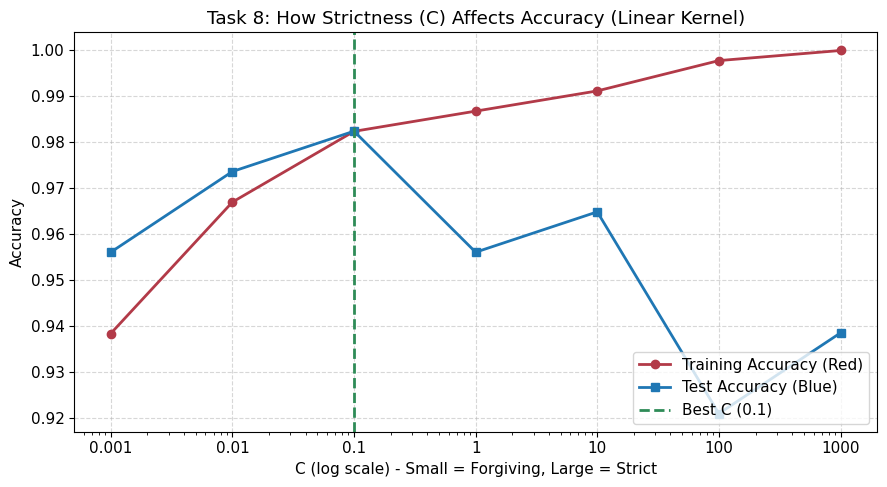

In [9]:
# ── Step 1: Set up the values to test ───────────────────────────────────────
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
results = []
train_scores = []
test_scores = []

# ── Step 2: Train and evaluate for each C ───────────────────────────────────
for C in c_values:
    # Use the scaled data (X_tr_s, X_te_s) from Task 6
    clf = SVC(kernel="linear", C=C)
    clf.fit(X_tr_s, y_tr)

    # Calculate accuracies and count support vectors
    train_acc = clf.score(X_tr_s, y_tr)
    test_acc = clf.score(X_te_s, y_te)
    n_sv = len(clf.support_)

    # Store for plotting
    train_scores.append(train_acc)
    test_scores.append(test_acc)

    # Store for the table
    results.append({
        "C Value": C,
        "Train Accuracy": f"{train_acc * 100:.2f}%",
        "Test Accuracy": f"{test_acc * 100:.2f}%",
        "Support Vectors": n_sv
    })

# ── Step 3: Print a clean table ─────────────────────────────────────────────
df_task8 = pd.DataFrame(results)
print("=== Task 8: C Dial on Breast Cancer Data ===")
print(df_task8.to_string(index=False))

# ── Step 4: Find the best C based on Test Accuracy ──────────────────────────
best_idx = np.argmax(test_scores)
best_c = c_values[best_idx]
print(f"\n-> Best C (highest test accuracy): {best_c}")

# ── Step 5: Plot the results ────────────────────────────────────────────────
plt.figure(figsize=(9, 5))

# Plot training (red/LO) and test (blue) scores on a log-scale x-axis
plt.semilogx(c_values, train_scores, color=LO, marker='o', linewidth=2, label='Training Accuracy (Red)')
plt.semilogx(c_values, test_scores, color='#1f77b4', marker='s', linewidth=2, label='Test Accuracy (Blue)')

# Draw vertical dashed green line (HI) at the best C
plt.axvline(x=best_c, color=HI, linestyle='--', linewidth=2, label=f'Best C ({best_c})')

plt.title("Task 8: How Strictness (C) Affects Accuracy (Linear Kernel)")
plt.xlabel("C (log scale) - Small = Forgiving, Large = Strict")
plt.ylabel("Accuracy")

# Format the x-axis to clearly show our chosen C values
plt.xticks(c_values, labels=c_values)

plt.legend(loc='lower right')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**💬 Think About It:**

*At what C does training accuracy reach about 100%?*  
*At what C is the test accuracy highest? Is it the same C that gives the best training accuracy?*  
*What happens to the number of support vectors as C increases? Is that the same pattern you saw on the salary data?*

<details><summary>💡 Reveal Solution</summary>

```python
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
tr_accs, te_accs, n_svs = [], [], []
print(f'{"C":>8}  {"Train Acc":>10}  {"Test Acc":>10}  {"Num SVs":>8}')
print('-' * 45)
for C in C_values:
    clf_c = SVC(kernel='linear', C=C).fit(X_tr_s, y_tr)
    tr = clf_c.score(X_tr_s, y_tr); te = clf_c.score(X_te_s, y_te); sv_n = len(clf_c.support_)
    tr_accs.append(tr); te_accs.append(te); n_svs.append(sv_n)
    print(f'{C:>8}  {tr:>10.4f}  {te:>10.4f}  {sv_n:>8}')
best_C = C_values[int(np.argmax(te_accs))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogx(C_values, tr_accs, 'o-', color='#E63946', label='Training accuracy')
axes[0].semilogx(C_values, te_accs, 's-', color='#457B9D', label='Test accuracy')
axes[0].axvline(best_C, color='green', lw=2, ls='--', label=f'Best C = {best_C}')
axes[0].set_xlabel('C  (log scale)'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('C vs Accuracy', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].semilogx(C_values, n_svs, 'D-', color='#F4A261')
axes[1].set_xlabel('C  (log scale)'); axes[1].set_ylabel('Number of support vectors')
axes[1].set_title('Larger C  →  fewer support vectors', fontweight='bold'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'\nBest C = {best_C}  →  Test accuracy = {max(te_accs):.4f}')
print('Note: with only 114 test patients, one patient = 0.9 points. In real projects choose C with cross-validation, not the test set.')
```
</details>

---
## ✏️ Task 9 — The Confusion Matrix: Not All Mistakes Are Equal  ⭐ *Bonus*

### Background
Accuracy hides the **type** of mistake. In cancer diagnosis:

| The model said... | Reality | Type | Consequence |
|---|---|---|---|
| Benign | Actually Malignant | **False Negative** | 🚨 Patient goes home — cancer untreated! |
| Malignant | Actually Benign | **False Positive** | 😟 Extra tests — stressful but safe |

A **False Negative** is far more dangerous. So: does the choice of C change the number of dangerous mistakes? (Next week's lecture on model evaluation goes much deeper.)

### Steps
1. Train linear SVMs with `C = 0.01, 1, 100` on the scaled cancer data
2. For each, plot a confusion matrix (3 subplots side by side)
3. Print the number of False Negatives for each C
4. Does the C with the best accuracy also have the fewest dangerous mistakes?

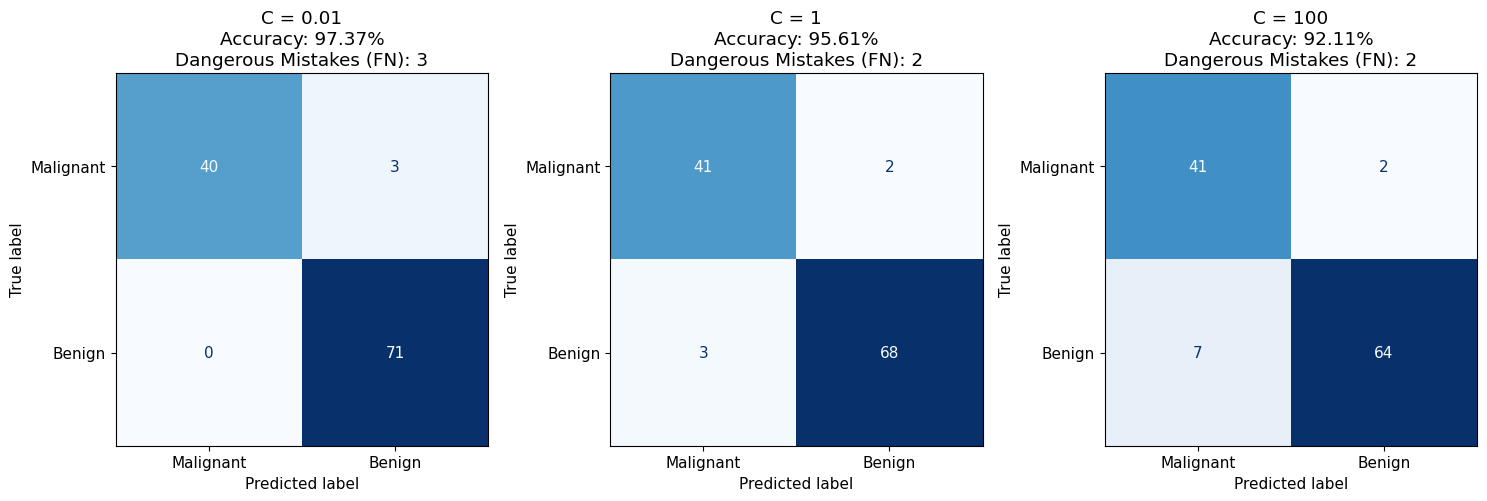

=== Task 9: Dangerous Mistakes Summary ===
C = 0.01   | Test Accuracy = 97.37% | False Negatives = 3
C = 1      | Test Accuracy = 95.61% | False Negatives = 2
C = 100    | Test Accuracy = 92.11% | False Negatives = 2


In [10]:
# ── Step 1: Set up the figure for 3 side-by-side subplots ───────────────────
c_values_bonus = [0.01, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

results_fn = []

# Note on labels for this dataset:
# 0 = Malignant (Dangerous)
# 1 = Benign (Safe)
# A "False Negative" in this medical context means:
# Reality is Malignant (0), but Model predicted Benign (1).

# ── Step 2: Train, Evaluate, and Plot for each C ────────────────────────────
for i, C in enumerate(c_values_bonus):
    # Train model
    clf = SVC(kernel="linear", C=C)
    clf.fit(X_tr_s, y_tr)

    # Predict on test set
    y_pred = clf.predict(X_te_s)
    acc = clf.score(X_te_s, y_te)

    # Generate confusion matrix
    cm = confusion_matrix(y_te, y_pred)

    # False Negative = Actual Malignant (Row 0), Predicted Benign (Col 1)
    false_negatives = cm[0, 1]
    results_fn.append((C, acc, false_negatives))

    # Plot the matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Malignant', 'Benign']
    )
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)

    axes[i].set_title(f"C = {C}\nAccuracy: {acc*100:.2f}%\nDangerous Mistakes (FN): {false_negatives}")
    axes[i].grid(False) # Turn off grid lines for cleaner matrix view

plt.tight_layout()
plt.show()

# ── Step 3: Print summary of False Negatives ────────────────────────────────
print("=== Task 9: Dangerous Mistakes Summary ===")
for C, acc, fn in results_fn:
    print(f"C = {C:<6} | Test Accuracy = {acc*100:.2f}% | False Negatives = {fn}")

**💬 Think About It:**

*Which C gives the fewest missed cancers?*  
*Is the C with the best overall accuracy also the safest for the patient?*  
*What does this tell you about choosing the right measure for a real-world problem?*

<details><summary>💡 Reveal Solution</summary>

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
print(f'{"C":>6}  {"Accuracy":>10}  {"False Negatives (missed cancer!)":>32}')
print('-' * 55)
for ax, C in zip(axes, [0.01, 1, 100]):
    clf_c = SVC(kernel='linear', C=C).fit(X_tr_s, y_tr)
    y_pred = clf_c.predict(X_te_s)
    acc = clf_c.score(X_te_s, y_te)
    fn = confusion_matrix(y_te, y_pred)[0, 1]       # actual malignant (0), predicted benign (1)
    print(f'{C:>6}  {acc:>10.4f}  {fn:>32}')
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=cancer.target_names, ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'C = {C}\nAcc={acc:.2f}  False Neg={fn}', fontweight='bold')
plt.suptitle('Breast Cancer: how C affects the type of mistake', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
---
# 🌸 PART 3 — Iris Flowers (Bonus)
## "Can a machine tell flower species apart from petal measurements?"

Iris has 3 species and only 4 measurements. Using just **two** (petal length and petal width) lets us **draw** what each kernel learns.

---

---
## ✏️ Task 10 — Linear vs RBF vs Polynomial: Draw the Boundaries  ⭐ *Bonus*

### Background
Different kernels draw different boundaries (remember the three-kernels slide): linear = straight lines, RBF = smooth curves in any direction, polynomial = curves from feature combinations.

SVM handles **3 classes** automatically: it splits the problem into several yes/no questions behind the scenes, so the code is exactly the same as for two classes.

The real question: does extra bending actually help on this data?

### Steps
1. Use only petal length and petal width (`iris.data[:, 2:4]`). Split 70/30 with `random_state=0`, scale (fit on train only)
2. Train 3 models, all with `C = 1`: `kernel="linear"`, `kernel="rbf"`, `kernel="poly"`
3. For each, draw the decision regions (coloured background), the training points, and circle the support vectors in gold
4. Show training **and** test accuracy in each title and print a comparison table
5. Which kernel generalises best? Is the most complex boundary always the best?

In [11]:
# ── Your code here ────────────────────────────────────────────────────────

**💬 Think About It:**

*Which kernel gives the highest test accuracy?*  
*Do the classes really need curved boundaries here?*  
*Is a more complex kernel always better? Connect your answer to what you saw in Task 4.*

<details><summary>💡 Reveal Solution</summary>

```python
X_pet = iris.data[:, 2:4]
X_ptr, X_pte, y_ptr, y_pte = train_test_split(X_pet, iris.target, test_size=0.3, random_state=0)
sc = StandardScaler()
X_ptr_s = sc.fit_transform(X_ptr)
X_pte_s = sc.transform(X_pte)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
print(f'{"Kernel":>10}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 35)
for ax, k in zip(axes, ['linear', 'rbf', 'poly']):
    clf_k = SVC(kernel=k, C=1).fit(X_ptr_s, y_ptr)
    tr = clf_k.score(X_ptr_s, y_ptr); te = clf_k.score(X_pte_s, y_pte)
    print(f'{k:>10}  {tr:>10.4f}  {te:>10.4f}')
    x_min, x_max = X_ptr_s[:, 0].min() - 0.5, X_ptr_s[:, 0].max() + 0.5
    y_min, y_max = X_ptr_s[:, 1].min() - 0.5, X_ptr_s[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = clf_k.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    for cls, color, name in zip([0, 1, 2], ['#E63946', '#2A9D8F', '#457B9D'], iris.target_names):
        m = (y_ptr == cls)
        ax.scatter(X_ptr_s[m, 0], X_ptr_s[m, 1], c=color, edgecolors='k', s=40, label=name, zorder=3)
    sv = clf_k.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=180, facecolors='none', edgecolors='gold', lw=2, zorder=4)
    ax.set_title(f'{k.capitalize()} kernel\nTrain={tr:.2f}  Test={te:.2f}', fontweight='bold')
    ax.set_xlabel('Petal length (scaled)'); ax.set_ylabel('Petal width (scaled)'); ax.legend(fontsize=8)
plt.suptitle('Iris: comparing kernels', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
```
</details>

---
## 📝 Final Reflection

*There are no right or wrong answers — just think it through and write your answers below.*

---

**Q1 — Support vectors:**  
In Task 2 only a few dots sat on the street edge, and in Task 7 a model trained on *only* the support vectors predicted like the full model. What does this tell you about how SVM "remembers" its training data compared with KNN, which keeps every dot?

**Q2 — The C parameter:**  
A classmate says: "I always set C = 1000 so the model works hard and makes fewer mistakes." Using Task 3 (the odd person) and Task 8, what would you say to them?

**Q3 — Kernels:**  
In Task 4, RBF scored 100% on the 20 people it studied, yet plain linear (with a larger C) did better on left-out people. Why can the simplest kernel win?

**Q4 — Scaling:**  
In Task 6, scaling helped the RBF model but barely changed the linear one. Why do we fit the scaler on the training data only, and not on the whole dataset?

**Q5 — Overfitting everywhere:**  
Compare K = 1 in KNN (Lecture 17), a very large C (Task 3) and a very large gamma (Task 5). What do all three have in common?

**Your answers:**

Q1:

Q2:

Q3:

Q4:

Q5:

---
## 🗺️ What You Covered

```
💼 Salary data  (Tasks 1–5)   — the same 20 people as the slides
   Task 1  →  Label the data and draw it
   Task 2  →  Find the hyperplane, the margin and the support vectors (score = 2×exp + 2×certs − 13)
   Task 3  →  Hard margin breaks with one odd person; the C dial widens or thins the street
   Task 4  →  Linear vs polynomial vs RBF, judged on left-out people (C matters as much as the kernel)
   Task 5  →  gamma: how an RBF model starts to memorise

🏥 Breast Cancer  (Tasks 6–8, bonus 9)
   Task 6  →  Scaling matters (for RBF) — with numbers
   Task 7  →  Prove that only support vectors decide the boundary
   Task 8  →  C on real data
   Task 9  →  Confusion matrix: not all mistakes are equal  ⭐

🌸 Iris  (bonus 10)
   Task 10 →  Draw what each kernel learns  ⭐
```

---
*🎓 Well done! Next week: how to compare models fairly (model evaluation).*